# Processamento de Sinais I — Aula Prática 2
## Questão 6 — Sobreamostragem com função própria

Relação usada:
$$y[n] = x[n/L]$$ para amostras múltiplas de $L$, e $$y[n] = 0$$ nos demais índices.

Objetivo: implementar a sobreamostragem por inserção de zeros, aplicar em `handel.wav` para fatores 2, 4 e 8, calcular o espectro e comentar os resultados.

## Importar bibliotecas e carregar a função de espectro

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile
from scipy import signal

def load_calculate_spectrum():
    notebook_path = Path('../tools/calculate_spectrum.ipynb')
    notebook = json.loads(notebook_path.read_text(encoding='utf-8'))

    namespace = {}
    for cell in notebook['cells']:
        if cell.get('cell_type') != 'code':
            continue

        source = ''.join(cell.get('source', []))
        exec(source, namespace)
        if 'calculate_spectrum' in namespace:
            return namespace['calculate_spectrum']

    raise RuntimeError('calculate_spectrum() nao encontrada em ../tools/calculate_spectrum.ipynb')

calculate_spectrum = load_calculate_spectrum()

plt.style.use('seaborn-v0_8-whitegrid')

def to_float_mono(data):
    data = np.asarray(data)
    if data.ndim > 1:
        data = data.mean(axis=1)
    if np.issubdtype(data.dtype, np.integer):
        data = data.astype(np.float64) / np.iinfo(data.dtype).max
    else:
        data = data.astype(np.float64)
    peak = np.max(np.abs(data))
    if peak > 1:
        data = data / peak
    return data


def show_audio(audio, rate, label):
    print(label)
    display(Audio(audio, rate=rate))


def plot_spectrum(signal_in, sampling_frequency, title, max_frequency=None):
    freqs, amps = calculate_spectrum(signal_in, sampling_frequency, single_sided=True)
    plt.figure(figsize=(12, 4))
    plt.plot(freqs, amps)
    if max_frequency is not None:
        plt.xlim(0, max_frequency)
    plt.title(title)
    plt.xlabel('Frequencia (Hz)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    return freqs, amps


## Definir a função de sobreamostragem

In [2]:
def sobreamostrar(signal_in, fator):
    y = np.zeros(len(signal_in) * fator)
    y[::fator] = signal_in
    return y


## Ler o áudio, sobreamostrar e analisar

Audio sobreamostrado com L = 2


Audio sobreamostrado com L = 4


Audio sobreamostrado com L = 8


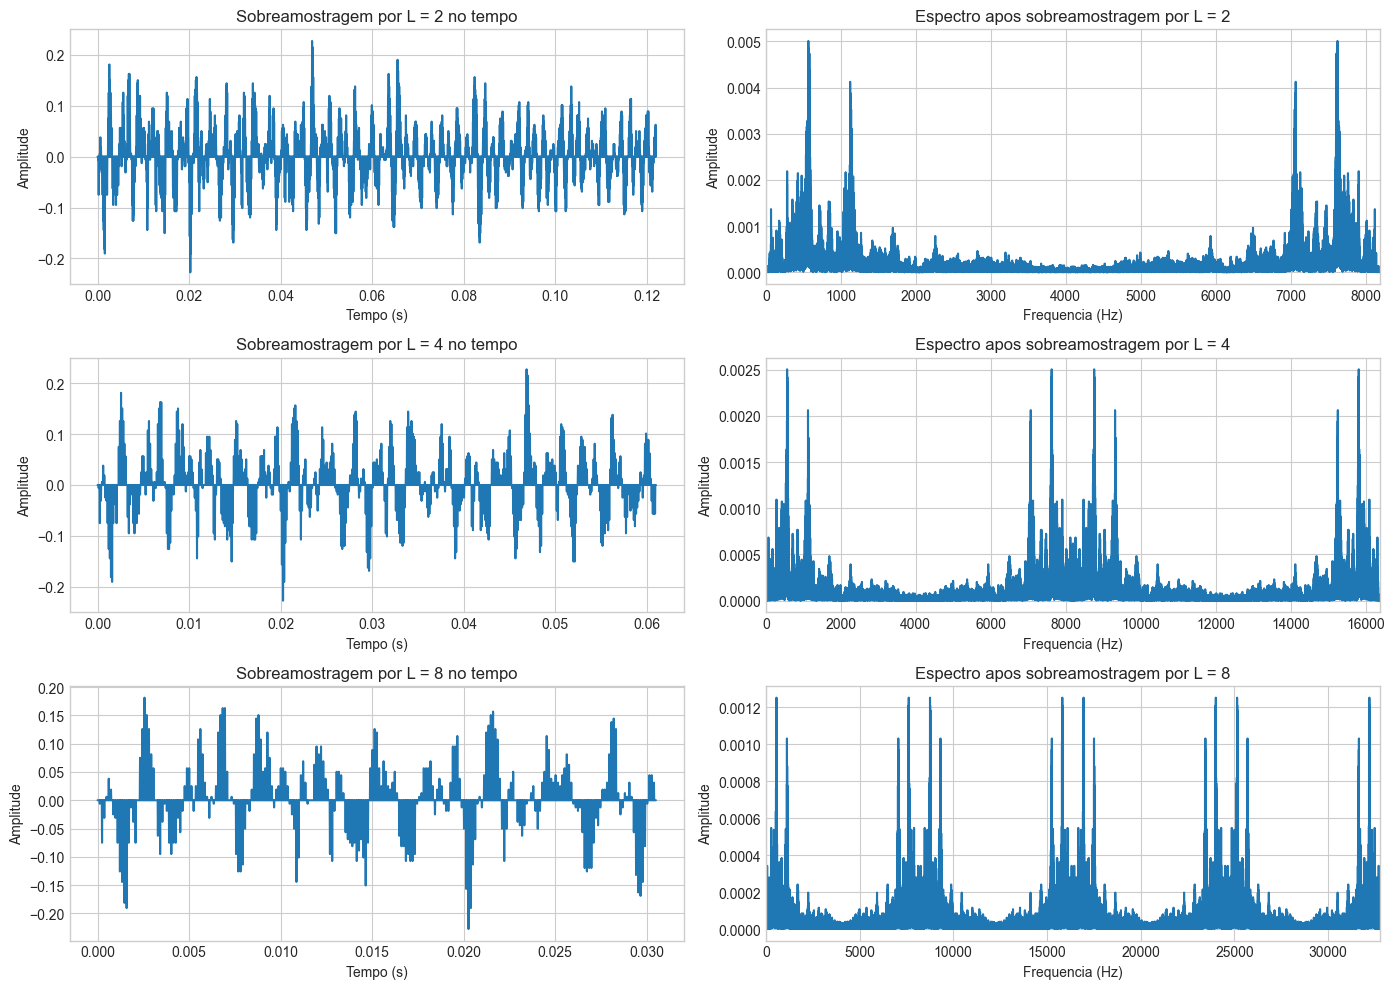

In [3]:
fs, audio_int = wavfile.read('../data/handel.wav')
audio = to_float_mono(audio_int)

fatores = [2, 4, 8]
sobreamostrados = {L: sobreamostrar(audio, L) for L in fatores}

fig, axes = plt.subplots(len(fatores), 2, figsize=(14, 10))
for i, L in enumerate(fatores):
    y = sobreamostrados[L]
    taxa = fs * L
    tempo = np.arange(len(y)) / taxa

    axes[i, 0].plot(tempo[:2000], y[:2000])
    axes[i, 0].set_title(f'Sobreamostragem por L = {L} no tempo')
    axes[i, 0].set_xlabel('Tempo (s)')
    axes[i, 0].set_ylabel('Amplitude')

    freqs, amps = calculate_spectrum(y, taxa, single_sided=True)
    axes[i, 1].plot(freqs, amps)
    axes[i, 1].set_xlim(0, taxa / 2)
    axes[i, 1].set_title(f'Espectro apos sobreamostragem por L = {L}')
    axes[i, 1].set_xlabel('Frequencia (Hz)')
    axes[i, 1].set_ylabel('Amplitude')

plt.tight_layout()

for L in fatores:
    taxa = fs * L
    show_audio(sobreamostrados[L], taxa, f'Audio sobreamostrado com L = {L}')


## Comentários

A inserção de zeros aumenta a taxa de amostragem, mas não cria informação nova no sinal. No espectro, isso aparece como imagens espectrais repetidas ao longo da banda.

Sem filtragem de interpolação após a inserção de zeros, o sinal contém réplicas espectrais e pode apresentar alterações perceptíveis. O conteúdo original continua presente, mas acompanhado dessas imagens.